<a href="https://colab.research.google.com/github/DataAnalytics808/DASC-522-demo-repository/blob/main/demos/Week_08_4_NN_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##8D NN Regularization

Demonstration modified from https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/overfit_and_underfit.ipynb

### Setup

Before getting started, import the necessary packages:

In [ ]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import regularizers
from  IPython import display
from matplotlib import pyplot as plt

import numpy as np

import pathlib
import tempfile


print(tf.__version__)

2.19.0


### The Higgs Dataset

The full Higgs dataset contains 11,000,000 examples, each with 28 features, and a binary class label. The total size in memory for a pandas dataframe is 2.4 GB when default 64 bit precision is used in a Pandas dataframe. Even though Colab RAM is larger than that, this tends to cause problems

In [ ]:

# If running on Colab, TF and TFDS are typically installed.
# If needed, uncomment the next line to ensure TFDS is present.
# !pip install -q tensorflow tensorflow-datasets

import os, math, numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
import pandas as pd


TensorFlow: 2.19.0
TFDS: 4.9.9


In [ ]:

# === Configuration ===
FEATURES = 28                 # HIGGS has 28 real-valued features
SUBSET_TOTAL = 1_100_000        # number of rows (reduce if you hit RAM limits)
TRAIN_FRACTION = 0.85          # 90% train / 10% validation
TRAIN_N = int(SUBSET_TOTAL * TRAIN_FRACTION)
VAL_N = SUBSET_TOTAL - TRAIN_N

SEED = 42

print(f"Using total subset: {SUBSET_TOTAL:,} rows → train={TRAIN_N:,}, val={VAL_N:,}")


Using total subset: 1,100,000 rows → train=935,000, val=165,000


In [ ]:
import os, gc, psutil, pandas as pd, numpy as np

# --- helpers ---
def _fmt_bytes(n):
    for unit in ("B","KB","MB","GB","TB"):
        if n < 1024 or unit == "TB":
            return f"{n:.2f} {unit}"
        n /= 1024

def show_ram(tag):
    proc = psutil.Process(os.getpid()).memory_info().rss
    vm   = psutil.virtual_memory()
    used = vm.total - vm.available
    print(f"[{tag}] System used: {_fmt_bytes(used)} / {_fmt_bytes(vm.total)}\n")

def show_obj(name, obj):
    if isinstance(obj, pd.DataFrame):
        n = int(obj.memory_usage(deep=True).sum())
    elif isinstance(obj, np.ndarray):
        n = int(obj.nbytes)
    else:
        import sys
        n = int(sys.getsizeof(obj))
    shape = getattr(obj, "shape", "")
    dtype = getattr(obj, "dtype", getattr(obj, "dtypes", ""))
    print(f"object information: {name:>10}: {_fmt_bytes(n)}  | shape={shape} dtype={dtype}\n")


In [ ]:
# # === Load subset directly from UCI gzip (stream first N rows) ===
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"

# show_ram("start")
# df = pd.read_csv(URL, compression="gzip", header=None, nrows=SUBSET_TOTAL)
# show_obj("df", df);
# show_ram("after df")


Save variables to Google cloud storage

In [ ]:
# import os
# import csv
# from google.colab import files


# # Ensure the target folder exists
# paths = '/content/gdrive/MyDrive/AFIT Files/Higgs dataset for class'
# os.chdir(paths)

# # === plain pickle ===
# pkl_path = os.path.join(paths, f"df_{len(df)}rows.pkl")
# df.to_pickle(pkl_path, protocol=4)   # protocol 4+ is efficient and widely compatible
# print("Saved:", pkl_path)


# # Quick size check
# if os.path.exists(pkl_path):
#     print(f"{pkl_path}  ->  {os.path.getsize(pkl_path)/1e6:.2f} MB")

# # === How to load later ===
# # df_loaded = pd.read_pickle(pkl_path)         # for plain .pkl


Load from cloud storage

In [ ]:
# Install gdown (Colab-friendly) and import libs
!pip -q install gdown

import gdown, pandas as pd

# shared link
url = "https://drive.google.com/file/d/16EkfxYVothQsK5A-W853NSmnuuk5EWW4/view?usp=sharing"

# Download to a local path (change if you prefer a different filename/location)
out_path = "/content/df_1100000rows.pkl"
gdown.download(url, out_path, quiet=False, fuzzy=True)

# Load the pickled DataFrame
df = pd.read_pickle(out_path)  # if you had a .pkl.gz, use: pd.read_pickle(out_path, compression="gzip")

print("Loaded:", out_path)
print("Shape:", df.shape)
print(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=16EkfxYVothQsK5A-W853NSmnuuk5EWW4
From (redirected): https://drive.google.com/uc?id=16EkfxYVothQsK5A-W853NSmnuuk5EWW4&confirm=t&uuid=ef54c62c-c60f-4826-9766-2e2d2095ede9
To: /content/df_1100000rows.pkl
100%|██████████| 255M/255M [00:02<00:00, 106MB/s]


Loaded: /content/df_1100000rows.pkl
Shape: (1100000, 29)
   0   1    2    3   4    5   6    7    8   9   10   11   12  13  14   15   16  17  18   19   20  21  22  23  24  25  26  27  28
0 1.0 0.9 -0.6  0.2 0.3 -0.7 0.8 -0.2 -1.1 0.0 1.4 -0.7  0.9 1.1 1.1 -1.6 -1.0 0.0 0.7 -0.0 -0.0 3.1 1.4 1.0 1.0 0.9 0.7 1.0 0.9
1 1.0 0.9  0.3  0.4 1.5 -0.3 1.1 -0.6 -1.6 2.2 0.8 -0.2  1.3 2.2 0.5 -1.3  0.7 0.0 0.4 -1.1 -0.0 0.0 0.3 0.8 1.0 1.0 0.8 1.0 0.8
2 1.0 0.8  1.5 -1.6 0.5  0.4 1.1  1.3  1.4 0.0 0.9  1.5 -0.8 2.2 1.0  0.4 -0.2 2.5 1.3  1.1  0.9 0.0 0.9 1.1 1.0 1.0 0.8 0.9 0.8
3 0.0 1.3 -0.9  0.9 2.0  0.9 1.8 -1.6 -0.9 0.0 2.4 -0.7  0.7 2.2 1.3 -1.4 -0.4 0.0 0.7 -0.7 -1.4 0.0 0.9 1.0 1.0 0.7 0.9 1.0 1.0
4 1.0 1.1  0.3  1.5 0.9 -1.2 0.7 -1.1 -0.9 0.0 0.8  1.0  1.0 2.2 0.6 -0.4  0.6 0.0 0.5 -0.4  0.1 0.0 0.8 1.4 1.0 0.8 1.1 0.9 0.8


Split dataset

In [ ]:

# Separate X and y as plain NumPy arrays (RAM-friendly dtypes)
y_all = df.iloc[:, 0].astype(np.int32).to_numpy()
show_obj("y_all", y_all); show_ram("after y_all")

X_all = df.iloc[:, 1:].astype(np.float32).to_numpy()
show_obj("X_all", X_all); show_ram("after X_all")

show_ram("df, y and X in memory")

del df; gc.collect()
show_ram("after del df")

# Deterministic shuffle, then split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(y_all))
show_obj("idx", idx); show_ram("after idx")

X_all = X_all[idx]
y_all = y_all[idx]
show_obj("X_all(shuf)", X_all)
show_obj("y_all(shuf)", y_all)
show_ram("after shuffle")

TRAIN_N = 10000
# VAL_N   = SUBSET_TOTAL - TRAIN_N

X_train, X_val = X_all[:TRAIN_N], X_all[TRAIN_N:100000]
y_train, y_val = y_all[:TRAIN_N], y_all[TRAIN_N:100000]
show_obj("X_train", X_train); show_obj("y_train", y_train)
show_obj("X_val",   X_val);   show_obj("y_val",   y_val)
show_ram("after split")

del X_all, y_all, idx; gc.collect()
show_ram("final (post-cleanup)")

object information:      y_all: 4.20 MB  | shape=(1100000,) dtype=int32

[after y_all] System used: 7.39 GB / 12.67 GB

object information:      X_all: 117.49 MB  | shape=(1100000, 28) dtype=float32

[after X_all] System used: 7.50 GB / 12.67 GB

[df, y and X in memory] System used: 7.50 GB / 12.67 GB

[after del df] System used: 7.30 GB / 12.67 GB

object information:        idx: 8.39 MB  | shape=(1100000,) dtype=int64

[after idx] System used: 7.28 GB / 12.67 GB

object information: X_all(shuf): 117.49 MB  | shape=(1100000, 28) dtype=float32

object information: y_all(shuf): 4.20 MB  | shape=(1100000,) dtype=int32

[after shuffle] System used: 7.32 GB / 12.67 GB

object information:    X_train: 1.07 MB  | shape=(10000, 28) dtype=float32

object information:    y_train: 39.06 KB  | shape=(10000,) dtype=int32

object information:      X_val: 9.61 MB  | shape=(90000, 28) dtype=float32

object information:      y_val: 351.56 KB  | shape=(90000,) dtype=int32

[after split] System used: 7.

In [ ]:


X_train.shape, y_train.shape, X_val.shape, y_val.shape


((10000, 28), (10000,), (90000, 28), (90000,))

In [ ]:

# === Standardize features ===
# Fit mean/std on train; apply to val.
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True)
std  = np.where(std < 1e-12, 1.0, std)  # avoid divide-by-zero for constant columns

X_train_std = (X_train - mean) / std
X_val_std   = (X_val   - mean) / std

print("Feature means (first 5):", mean.ravel()[:5])
print("Feature stds  (first 5):", std.ravel()[:5])
print("Standardized shapes:", X_train_std.shape, X_val_std.shape)


Feature means (first 5): [ 0.989  0.012 -0.015  1.003  0.007]
Feature stds  (first 5): [0.555 1.003 1.008 0.598 1.   ]
Standardized shapes: (10000, 28) (90000, 28)


In [ ]:

tf.random.set_seed(SEED)
np.random.seed(SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(FEATURES,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')   # binary class (0/1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_158 (Dense)               │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_160 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

EPOCHS = 5
BATCH_SIZE = 128  # moderate batch to keep RAM/GPU usage reasonable

history = model.fit(
    X_train_std, y_train,
    validation_data=(X_val_std, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5733 - loss: 0.6760 - val_accuracy: 0.6160 - val_loss: 0.6539
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6317 - loss: 0.6406 - val_accuracy: 0.6340 - val_loss: 0.6393
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6521 - loss: 0.6238 - val_accuracy: 0.6425 - val_loss: 0.6317
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6664 - loss: 0.6114 - val_accuracy: 0.6485 - val_loss: 0.6267
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6773 - loss: 0.6013 - val_accuracy: 0.6521 - val_loss: 0.6234


Validation — loss: 0.6234  acc: 0.6521
Validation AUC: 0.7069


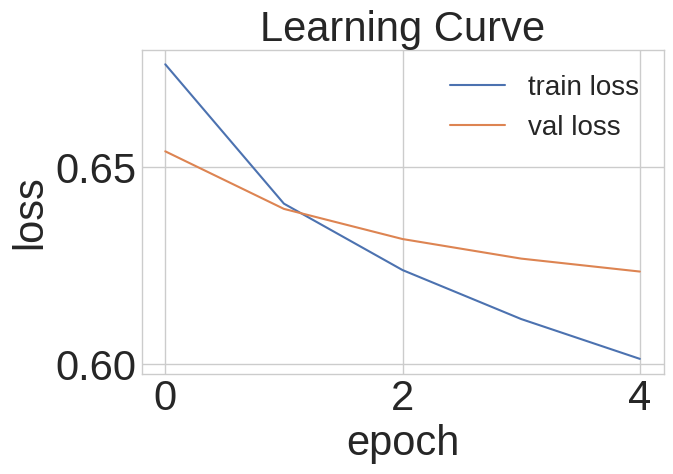

In [ ]:

# Basic evaluation
val_loss, val_acc = model.evaluate(X_val_std, y_val, verbose=0)
print(f"Validation — loss: {val_loss:.4f}  acc: {val_acc:.4f}")

# AUC for a better sense on imbalanced-ish data
y_val_pred = model.predict(X_val_std, batch_size=4096, verbose=0).ravel()
try:
    auc = roc_auc_score(y_val, y_val_pred)
    print(f"Validation AUC: {auc:.4f}")
except Exception as e:
    print("AUC not available:", e)

# Quick learning curves
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Learning Curve'); plt.show()


In [ ]:

# Rough RAM estimate for arrays (ignores Python overhead)
def bytes_to_mb(x): return x / (1024*1024)
ram_mb = (X_train.nbytes + y_train.nbytes + X_val.nbytes + y_val.nbytes
          + X_train_std.nbytes + X_val_std.nbytes)
print(f"Approx array RAM footprint: {bytes_to_mb(ram_mb):.1f} MB")

Approx array RAM footprint: 21.7 MB


### Demonstrate overfitting

The simplest way to prevent overfitting is to start with a small model: A model with a small number of learnable parameters (which is determined by the number of layers and the number of units per layer). In deep learning, the number of learnable parameters in a model is often referred to as the model's "capacity".

Intuitively, a model with more parameters will have more "memorization capacity" and therefore will be able to easily learn a perfect dictionary-like mapping between training samples and their targets, a mapping without any generalization power, but this would be useless when making predictions on previously unseen data.

Always keep this in mind: deep learning models tend to be good at fitting to the training data, but the real challenge is generalization, not fitting.

On the other hand, if the network has limited memorization resources, it will not be able to learn the mapping as easily. To minimize its loss, it will have to learn compressed representations that have more predictive power. At the same time, if you make your model too small, it will have difficulty fitting to the training data. There is a balance between "too much capacity" and "not enough capacity".

Unfortunately, there is no magical formula to determine the right size or architecture of your model (in terms of the number of layers, or the right size for each layer). You will have to experiment using a series of different architectures.

To find an appropriate model size, it's best to start with relatively few layers and parameters, then begin increasing the size of the layers or adding new layers until you see diminishing returns on the validation loss.

Start with a simple model using only `layers.Dense` as a baseline, then create larger versions, and compare them.

### Training procedure

Many models train better if you gradually reduce the learning rate during training. Use `optimizers.schedules` to reduce the learning rate over time:

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
  0.01,
  decay_steps=50, # how many steps until decay
  decay_rate=1,
  staircase=False)

def get_optimizer():
  return tf.keras.optimizers.Adam(lr_schedule)

The code above sets a `schedules.InverseTimeDecay` to hyperbolically decrease the learning rate to 1/2 of the base rate at 1000 epochs, 1/3 at 2000 epochs and so on.

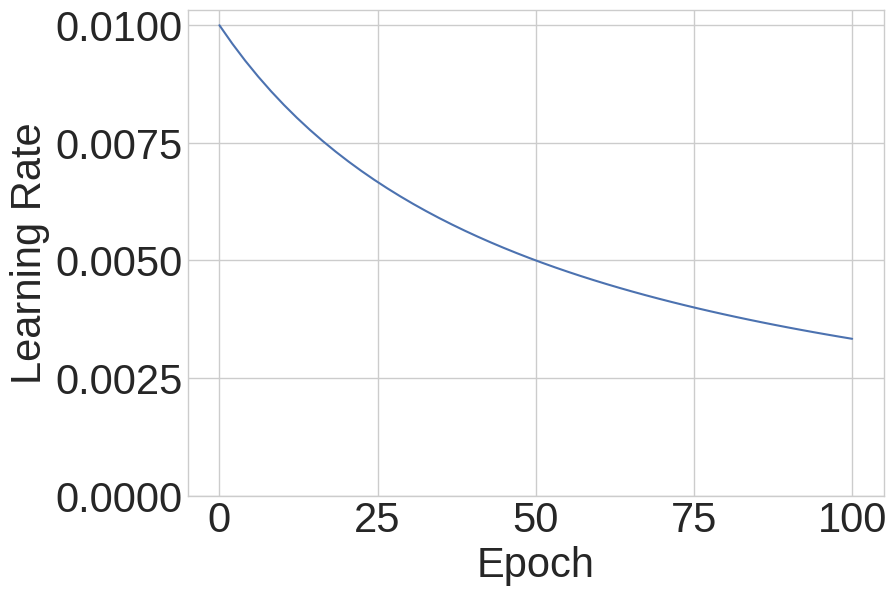

In [ ]:
step = np.linspace(0,100)
lr = lr_schedule(step)
plt.figure(figsize = (8,6))
plt.plot(step, lr)
plt.ylim([0,max(plt.ylim())])
plt.xlabel('Epoch')
_ = plt.ylabel('Learning Rate')


Each model in this tutorial will use the same training configuration. So set these up in a reusable way, starting with the list of callbacks.

 `callbacks.EarlyStopping` to avoid long and unnecessary training times. Note that this callback is set to monitor the `val_binary_crossentropy`, not the `val_loss`. This difference will be important later.



In [ ]:
def get_callbacks(name):
  return [
    tf.keras.callbacks.EarlyStopping(monitor='val_binary_crossentropy', patience=20),
  ]

Similarly each model will use the same `Model.compile` and `Model.fit` settings:

In [ ]:
def compile_and_fit(model, name, optimizer=None, max_epochs=100): # was 5000
  if optimizer is None:
    optimizer = get_optimizer()

  model.compile(optimizer=optimizer,
                loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=[
                  tf.keras.losses.BinaryCrossentropy(
                      from_logits=True, name='binary_crossentropy'),
                  'accuracy'])

  model.summary()

  history = model.fit(
    X_train_std, y_train,
    validation_data=(X_val_std, y_val),
    batch_size = 128,
    epochs=max_epochs,
    # callbacks=get_callbacks(name),
    verbose=1)
  return history

### Tiny model

Start by training a model:

In [ ]:
tiny_model = tf.keras.Sequential([
    layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
size_histories = {}

In [ ]:
size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny')

Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_161 (Dense)               │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5336 - binary_crossentropy: 0.6760 - loss: 0.6765 - val_accuracy: 0.5755 - val_binary_crossentropy: 0.6496 - val_loss: 0.6497
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5783 - binary_crossentropy: 0.6421 - loss: 0.6422 - val_accuracy: 0.5841 - val_binary_crossentropy: 0.6426 - val_loss: 0.6427
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5879 - binary_crossentropy: 0.6357 - loss: 0.6359 - val_accuracy: 0.5889 - val_binary_crossentropy: 0.6390 - val_loss: 0.6391
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5929 - binary_crossentropy: 0.6319 - loss: 0.6320 - val_accuracy: 0.5925 - val_binary_crossentropy: 0.6368 - val_loss: 0.6369
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5987 - binary_crossentropy: 0.6292 - loss: 0.6294 - val_accuracy: 0.5960 - val_binary_crossentropy: 0.6353 - val_loss: 0.6354
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2

Now check how the model did:

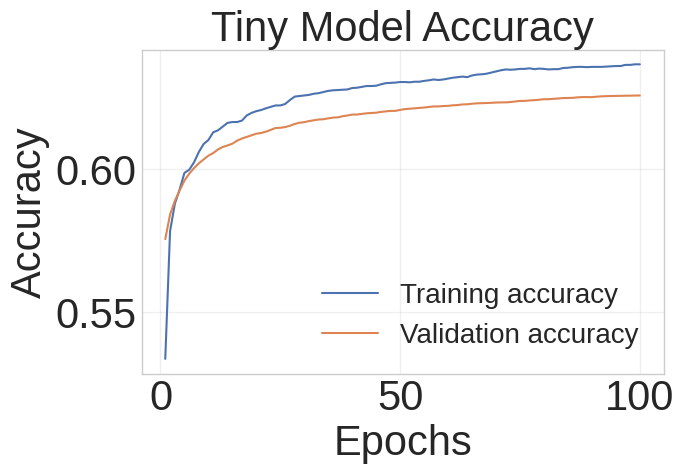

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy(history, title="Accuracy"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, label='Training accuracy')
    plt.plot(epochs, val_acc, label='Validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example: plot accuracy for the Tiny model
plot_accuracy(size_histories['Tiny'], title="Tiny Model Accuracy")


### Small model

To see if you can beat the performance of the small model, progressively train some larger models.

Try two hidden layers with 16 units each:

In [ ]:
small_model = tf.keras.Sequential([
    # `input_shape` is only required here so that `.summary` works.
    layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])

Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_163 (Dense)               │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_164 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_165 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753 (2.94 KB)

 Trainable params: 753 (2.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5540 - binary_crossentropy: 0.6543 - loss: 0.6546 - val_accuracy: 0.6027 - val_binary_crossentropy: 0.6391 - val_loss: 0.6392
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6111 - binary_crossentropy: 0.6269 - loss: 0.6272 - val_accuracy: 0.6165 - val_binary_crossentropy: 0.6308 - val_loss: 0.6309
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6251 - binary_crossentropy: 0.6187 - loss: 0.6189 - val_accuracy: 0.6228 - val_binary_crossentropy: 0.6270 - val_loss: 0.6271
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6329 - binary_crossentropy: 0.6137 - loss: 0.6140 - val_accuracy: 0.6274 - val_binary_crossentropy: 0.6247 - val_loss: 0.6248
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6394 - binary_crossentropy: 0.6103 - loss: 0.6106 - val_accuracy: 0.6304 - val_binary_crossentropy: 0.6231 - val_loss: 0.6232
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━

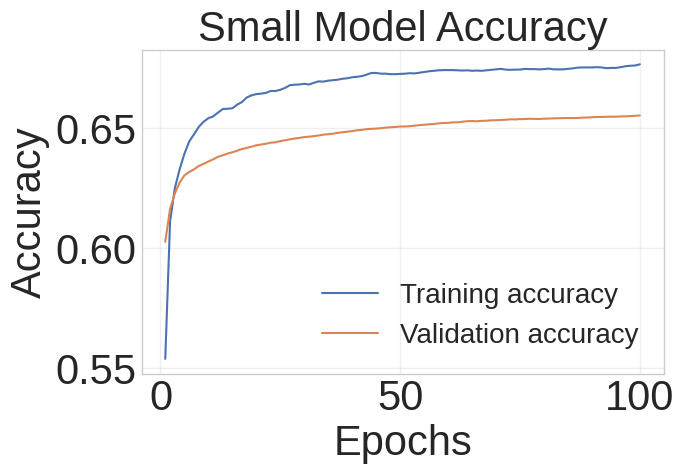

In [ ]:
size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small')
plot_accuracy(size_histories['Small'], title="Small Model Accuracy")


### Medium model

Now try 3 hidden layers with 64 units each:

In [ ]:
medium_model = tf.keras.Sequential([
    layers.Dense(64, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(64, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(1)
])

And train the model using the same data:

Model: "sequential_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_166 (Dense)               │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5799 - binary_crossentropy: 0.6523 - loss: 0.6517 - val_accuracy: 0.6428 - val_binary_crossentropy: 0.6302 - val_loss: 0.6303
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6325 - binary_crossentropy: 0.6126 - loss: 0.6125 - val_accuracy: 0.6576 - val_binary_crossentropy: 0.6171 - val_loss: 0.6173
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6535 - binary_crossentropy: 0.5977 - loss: 0.5982 - val_accuracy: 0.6618 - val_binary_crossentropy: 0.6079 - val_loss: 0.6081
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6661 - binary_crossentropy: 0.5867 - loss: 0.5874 - val_accuracy: 0.6643 - val_binary_crossentropy: 0.6023 - val_loss: 0.6025
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6759 - binary_crossentropy: 0.5773 - loss: 0.5783 - val_accuracy: 0.6683 - val_binary_crossentropy: 0.5989 - val_loss: 0.5991
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3

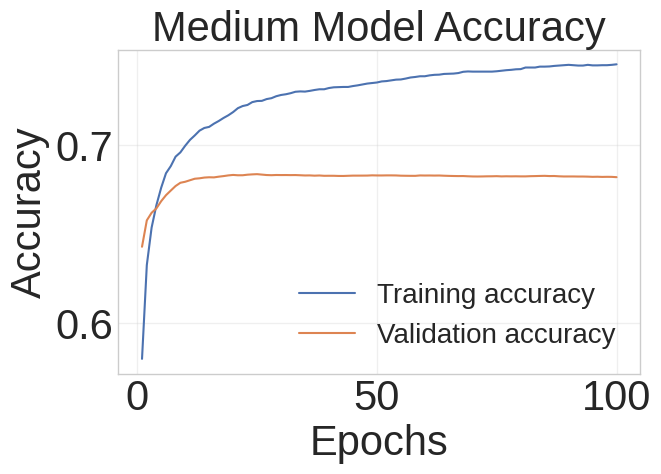

In [ ]:
size_histories['Medium']  = compile_and_fit(medium_model, "sizes/Medium")
plot_accuracy(size_histories['Medium'], title="Medium Model Accuracy")


### Large model

As an exercise, you can create an even larger model, and see how quickly it begins overfitting.  Next, let's add to this benchmark a network that has much more capacity, far more than the problem would warrant:

In [ ]:
large_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(1)
])

And, again, train the model using the same data:

Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_170 (Dense)               │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,329 (3.06 MB)

 Trainable params: 803,329 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5011 - binary_crossentropy: 1.8040 - loss: 1.8163 - val_accuracy: 0.5801 - val_binary_crossentropy: 0.7084 - val_loss: 0.7084
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5552 - binary_crossentropy: 0.6646 - loss: 0.6639 - val_accuracy: 0.6005 - val_binary_crossentropy: 0.6762 - val_loss: 0.6764
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5915 - binary_crossentropy: 0.6409 - loss: 0.6411 - val_accuracy: 0.6223 - val_binary_crossentropy: 0.6483 - val_loss: 0.6484
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6109 - binary_crossentropy: 0.6246 - loss: 0.6247 - val_accuracy: 0.6268 - val_binary_crossentropy: 0.6424 - val_loss: 0.6426
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6286 - binary_crossentropy: 0.6143 - loss: 0.6144 - val_accuracy: 0.6295 - val_binary_crossentropy: 0.6375 - val_loss: 0.6376
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2

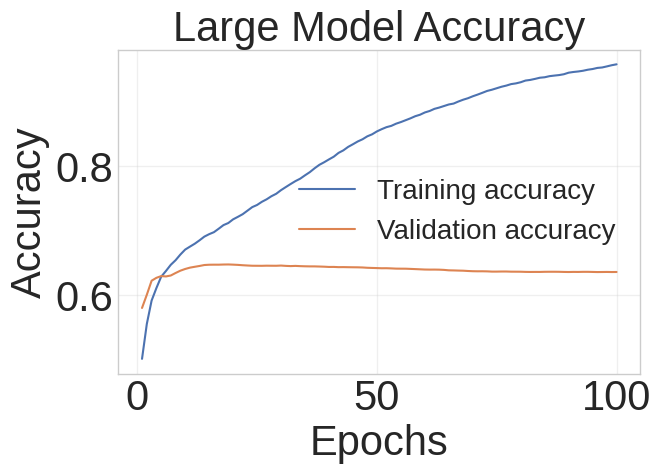

In [ ]:
size_histories['Large'] = compile_and_fit(large_model, "sizes/large")
plot_accuracy(size_histories['Large'], title="Large Model Accuracy")


### Plot the training and validation losses

The solid lines show the training loss, and the dashed lines show the validation loss (remember: a lower validation loss indicates a better model).

While building a larger model gives it more power, if this power is not constrained somehow it can easily overfit to the training set.

In this example, typically, only the `"Tiny"` model manages to avoid overfitting altogether, and each of the larger models overfit the data more quickly. This becomes so severe for the `"large"` model that you need to switch the plot to a log-scale to really see what's happening.

This is apparent if you plot and compare the validation metrics to the training metrics.

* It's normal for there to be a small difference.
* If both metrics are moving in the same direction, everything is fine.
* If the validation metric begins to stagnate while the training metric continues to improve, you are probably close to overfitting.
* If the validation metric is going in the wrong direction, the model is clearly overfitting.

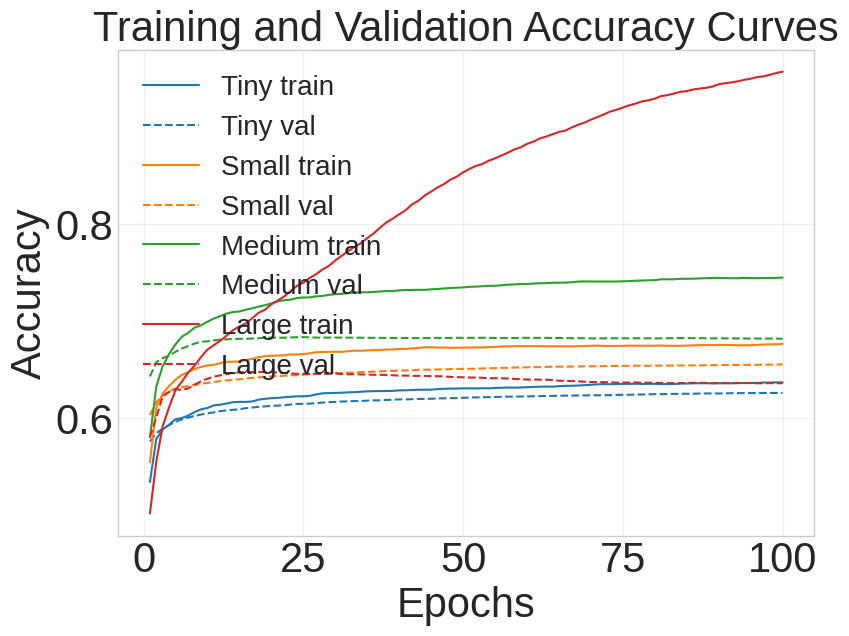

In [ ]:
import matplotlib.pyplot as plt

colors = {
    "Tiny":   "tab:blue",
    "Small":  "tab:orange",
    "Medium": "tab:green",
    "Large":  "tab:red"
}

plt.figure(figsize=(8,6))

for name, history in size_histories.items():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, color=colors[name], linestyle='-',  label=f"{name} train")
    plt.plot(epochs, val_acc, color=colors[name], linestyle='--', label=f"{name} val")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Note: All the above training runs used the `callbacks.EarlyStopping` to end the training once it was clear the model was not making progress.

### Strategies to prevent overfitting

In [ ]:
regularizer_histories = {}
regularizer_histories['Tiny'] = size_histories['Tiny']

### Add weight regularization


You may be familiar with Occam's Razor principle: given two explanations for something, the explanation most likely to be correct is the "simplest" one, the one that makes the least amount of assumptions. This also applies to the models learned by neural networks: given some training data and a network architecture, there are multiple sets of weights values (multiple models) that could explain the data, and simpler models are less likely to overfit than complex ones.

A "simple model" in this context is a model where the distribution of parameter values has less entropy (or a model with fewer parameters altogether, as we saw in the section above). Thus a common way to mitigate overfitting is to put constraints on the complexity of a network by forcing its weights only to take small values, which makes the distribution of weight values more "regular". This is called "weight regularization", and it is done by adding to the loss function of the network a cost associated with having large weights. This cost comes in two flavors:

* [L1 regularization](https://developers.google.com/machine-learning/glossary/#L1_regularization), where the cost added is proportional to the absolute value of the weights coefficients (i.e. to what is called the "L1 norm" of the weights).

* [L2 regularization](https://developers.google.com/machine-learning/glossary/#L2_regularization), where the cost added is proportional to the square of the value of the weights coefficients (i.e. to what is called the squared "L2 norm" of the weights). L2 regularization is also called weight decay in the context of neural networks. Don't let the different name confuse you: weight decay is mathematically the exact same as L2 regularization.

L1 regularization pushes weights towards exactly zero encouraging a sparse model. L2 regularization will penalize the weights parameters without making them sparse since the penalty goes to zero for small weights. one reason why L2 is more common.

In `tf.keras`, weight regularization is added by passing weight regularizer instances to layers as keyword arguments. Let's add L2 weight regularization now.

In [ ]:
l2_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1)
])

regularizer_histories['l2'] = compile_and_fit(l2_model, "regularizers/l2")

Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_175 (Dense)               │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,329 (3.06 MB)

 Trainable params: 803,329 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5052 - binary_crossentropy: 1.4189 - loss: 2.9758 - val_accuracy: 0.5725 - val_binary_crossentropy: 0.6844 - val_loss: 1.8527
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5551 - binary_crossentropy: 0.6560 - loss: 1.5572 - val_accuracy: 0.6080 - val_binary_crossentropy: 0.6456 - val_loss: 1.3373
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5869 - binary_crossentropy: 0.6365 - loss: 1.2062 - val_accuracy: 0.6143 - val_binary_crossentropy: 0.6353 - val_loss: 1.1030
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6016 - binary_crossentropy: 0.6291 - loss: 1.0297 - val_accuracy: 0.6247 - val_binary_crossentropy: 0.6330 - val_loss: 0.9756
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6017 - binary_crossentropy: 0.6256 - loss: 0.9274 - val_accuracy: 0.6258 - val_binary_crossentropy: 0.6306 - val_loss: 0.8961
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value**2` to the total **loss** of the network.

That is why we're monitoring the `binary_crossentropy` directly. Because it doesn't have this regularization component mixed in.

So, that same `"Large"` model with an `L2` regularization penalty performs much better:


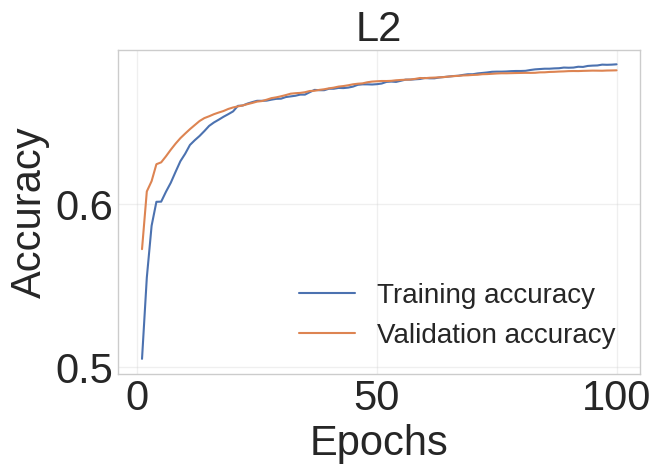

In [ ]:
plot_accuracy(regularizer_histories['l2'], title="L2")


As you can see, the `"L2"` regularized model is now much more competitive with the the `"Tiny"` model. This `"L2"` model is also much more resistant to overfitting than the `"Large"` model it was based on despite having the same number of parameters.

### Add dropout

Dropout is one of the most effective and most commonly used regularization techniques for neural networks, developed by Hinton and his students at the University of Toronto.

The intuitive explanation for dropout is that because individual nodes in the network cannot rely on the output of the others, each node must output features that are useful on their own.

Dropout, applied to a layer, consists of randomly "dropping out" (i.e. set to zero) a number of output features of the layer during training. Let's say a given layer would normally have returned a vector [0.2, 0.5, 1.3, 0.8, 1.1] for a given input sample during training; after applying dropout, this vector will have a few zero entries distributed at random, e.g. [0, 0.5,
1.3, 0, 1.1].

The "dropout rate" is the fraction of the features that are being zeroed-out; it is usually set between 0.2 and 0.5. At test time, no units are dropped out, and instead the layer's output values are scaled down by a factor equal to the dropout rate, so as to balance for the fact that more units are active than at training time.

In `tf.keras` you can introduce dropout in a network via the Dropout layer, which gets applied to the output of layer right before.

Let's add two Dropout layers in our network to see how well they do at reducing overfitting:

In [ ]:
dropout_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

regularizer_histories['dropout'] = compile_and_fit(dropout_model, "regularizers/dropout")

Model: "sequential_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_180 (Dense)               │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,329 (3.06 MB)

 Trainable params: 803,329 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.5339 - binary_crossentropy: 0.9862 - loss: 0.9901 - val_accuracy: 0.6028 - val_binary_crossentropy: 0.6791 - val_loss: 0.6792
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5508 - binary_crossentropy: 0.6829 - loss: 0.6837 - val_accuracy: 0.6188 - val_binary_crossentropy: 0.6580 - val_loss: 0.6581
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5603 - binary_crossentropy: 0.6570 - loss: 0.6576 - val_accuracy: 0.6270 - val_binary_crossentropy: 0.6442 - val_loss: 0.6443
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5710 - binary_crossentropy: 0.6522 - loss: 0.6531 - val_accuracy: 0.6321 - val_binary_crossentropy: 0.6428 - val_loss: 0.6430
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5889 - binary_crossentropy: 0.6417 - loss: 0.6416 - val_accuracy: 0.6181 - val_binary_crossentropy: 0.6312 - val_loss: 0.6314
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 

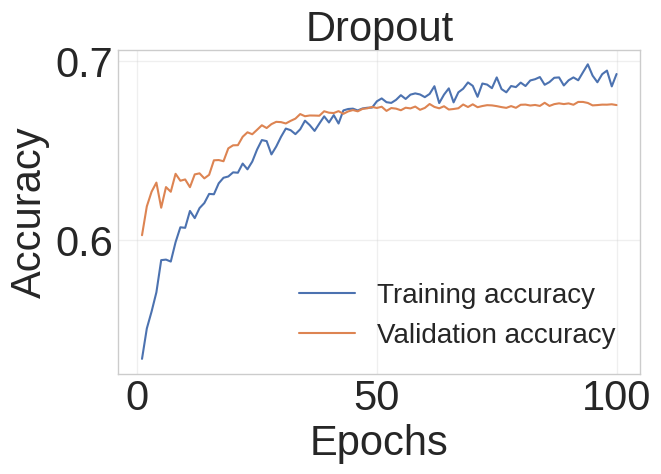

In [ ]:
plot_accuracy(regularizer_histories['dropout'], title="Dropout")


It's clear from this plot that both of these regularization approaches improve the behavior of the `"Large"` model. But this still doesn't beat even the `"Tiny"` baseline.

Next try them both, together, and see if that does better.

### Combined L2 + dropout

In [ ]:
combined_model = tf.keras.Sequential([
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

regularizer_histories['combined'] = compile_and_fit(combined_model, "regularizers/combined")

Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_185 (Dense)               │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_186 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_187 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,329 (3.06 MB)

 Trainable params: 803,329 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.5296 - binary_crossentropy: 1.0299 - loss: 1.3150 - val_accuracy: 0.6152 - val_binary_crossentropy: 0.6671 - val_loss: 0.9717
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5528 - binary_crossentropy: 0.6724 - loss: 0.9703 - val_accuracy: 0.6375 - val_binary_crossentropy: 0.6421 - val_loss: 0.9312
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5822 - binary_crossentropy: 0.6478 - loss: 0.9303 - val_accuracy: 0.6465 - val_binary_crossentropy: 0.6388 - val_loss: 0.9142
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5929 - binary_crossentropy: 0.6423 - loss: 0.9126 - val_accuracy: 0.6457 - val_binary_crossentropy: 0.6359 - val_loss: 0.8993
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6095 - binary_crossentropy: 0.6329 - loss: 0.8914 - val_accuracy: 0.6438 - val_binary_crossentropy: 0.6272 - val_loss: 0.8801
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 

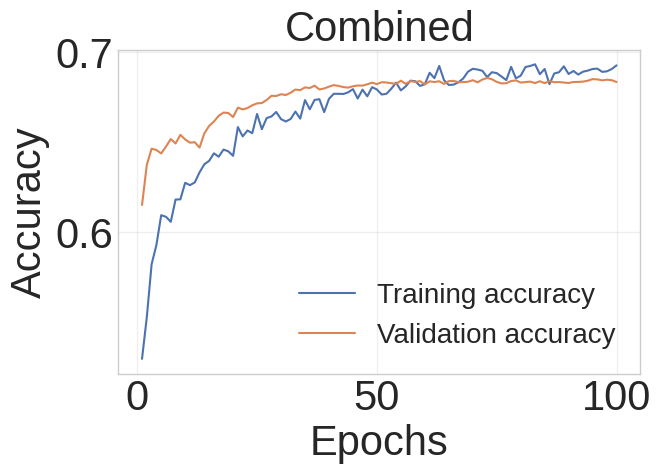

In [ ]:
plot_accuracy(regularizer_histories['combined'], title="Combined")


In [ ]:
regularizer_histories

{'Tiny': <keras.src.callbacks.history.History at 0x7bf84065d1c0>,
 'l2': <keras.src.callbacks.history.History at 0x7bf824c62180>,
 'dropout': <keras.src.callbacks.history.History at 0x7bf823fbcbc0>,
 'combined': <keras.src.callbacks.history.History at 0x7bf8248fb0b0>}

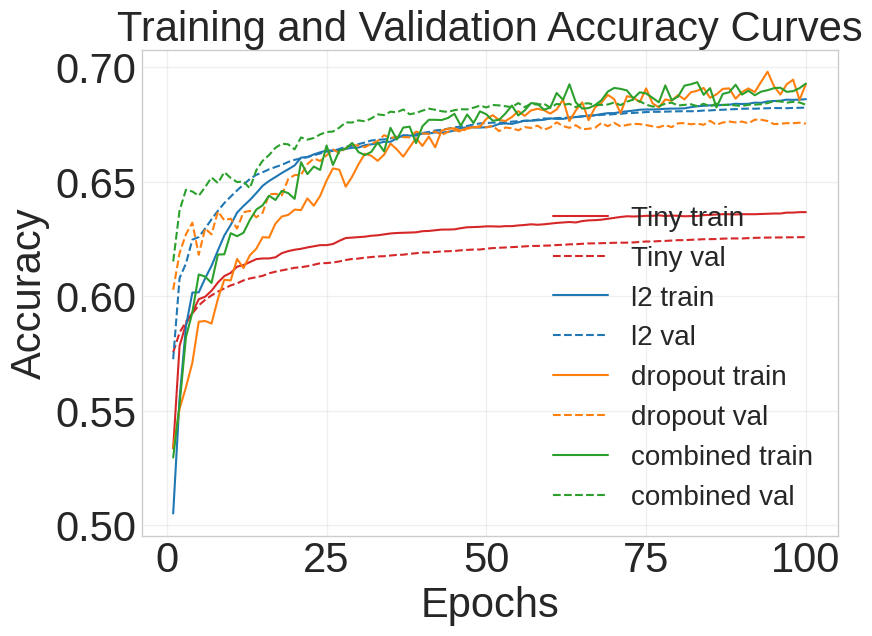

In [ ]:
import matplotlib.pyplot as plt
plt.show()
colors2 = {
    "Tiny":   "tab:red",
    "l2":   "tab:blue",
    "dropout":  "tab:orange",
    "combined": "tab:green",
}

plt.figure(figsize=(8,6))

for name, history in regularizer_histories.items():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, color=colors2[name], linestyle='-',  label=f"{name} train")
    plt.plot(epochs, val_acc, color=colors2[name], linestyle='--', label=f"{name} val")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Conclusions

To recap: here are the most common ways to prevent overfitting in neural networks:

* Get more training data.
* Reduce the capacity of the network.
* Add weight regularization.
* Add dropout.

Two important approaches not covered in this guide are:

* data-augmentation
* batch normalization

Remember that each method can help on its own, but combining them can be beneficial as well.